In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import scanpy as sc
import datetime
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from matplotlib import style
from perturbgen.configs import ROOT

from perturbgen.src.metric import (
    evaluate_emd,
)


In [3]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [4]:
np.random.seed(42)
random.seed(42)

In [5]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [6]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [7]:
res_dir = 'T_perturb/res/hspc/tf_perturbation_pp/'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

In [8]:
adata_tf_pert = sc.read_h5ad('/nfs/team361/am74/Cytomeister/Evaluation_datasets/HSPC_invitro_perturbseq/processed_data.h5ad')

In [9]:
adata_tf_pert

AnnData object with n_obs × n_vars = 92286 × 15662
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [10]:
# print replicate 

In [11]:
adata_tf_pert.X[:10, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.75964355, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.61787355, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.61787355],
       [0.        , 0.        , 0.9200551 , 0.9200551 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.9278564 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.519982  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.       

In [12]:
adata_tf_pert.layers['counts'][:10, :10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 2., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 1., 0., 0., 2., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [13]:
adata_terminal = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/tokenized_data/hspc_pbmc_median_inter_tissue_all_tf_100M/h5ad_pairing_5000_hvg_tgt/1_terminal.h5ad')

In [14]:
adata_terminal.X[:10, :10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 2., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [15]:
sc.pp.normalize_total(adata_terminal)
sc.pp.log1p(adata_terminal)

In [16]:
adata_terminal.obs.celltype_v2.value_counts()
# remove empty categories from the categorical dtype
if pd.api.types.is_categorical_dtype(adata_terminal.obs['celltype_v2']):
    adata_terminal.obs['celltype_v2'] = adata_terminal.obs['celltype_v2'].cat.remove_unused_categories()
else:
    adata_terminal.obs['celltype_v2'] = adata_terminal.obs['celltype_v2'].astype('category').cat.remove_unused_categories()

# confirm
adata_terminal.obs['celltype_v2'].value_counts(), adata_terminal.obs['celltype_v2'].cat.categories


/tmp/ipykernel_851836/1233789207.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata_terminal.obs['celltype_v2']):


(celltype_v2
 Pro_B            10958
 Early_Ery        10660
 Large_Pre_B       3335
 Cycling_Pro_B     3192
 Mono_pre          2746
 Late_Ery          2603
 pDC               2170
 DC_pre            2124
 MK                1669
 BaEoMa            1609
 Immature_B         960
 Macrophage         880
 Small_Pre_B        658
 PreProB            456
 Name: count, dtype: int64,
 Index(['BaEoMa', 'Cycling_Pro_B', 'DC_pre', 'Early_Ery', 'Immature_B',
        'Large_Pre_B', 'Late_Ery', 'MK', 'Macrophage', 'Mono_pre', 'PreProB',
        'Pro_B', 'Small_Pre_B', 'pDC'],
       dtype='object'))

In [17]:
adata_tf_pert

AnnData object with n_obs × n_vars = 92286 × 15662
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [18]:
adata_tf_pert.obs.new_CellType.value_counts()

new_CellType
Pro-Erythroblast               33381
Polychromatic Erythroblast     18050
Basophilic Erythroblast        14603
EoBasoMast Precursor            9393
CFU-E                           8162
Orthochromatic Erythroblast     2485
BFU-E                           2068
Megakaryocyte Precursor          815
MEP                              565
Early GMP                        228
Name: count, dtype: int64

In [19]:
adata_terminal

AnnData object with n_obs × n_vars = 44020 × 5700
    obs: 'index', 'assignment_id', 'age', 'sex', 'tissue', 'phase', 'S_score', 'G2M_score', 'celltype_v2', 'donor_tissue', 'diff_state', 'dataset', 'n_counts', 'n_genes', 'cell_pairing_index'
    var: 'gene_name', 'ensembl_id', 'token_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'row_id'
    uns: 'log1p'

### 1. Explore TF perturbation data

In [20]:
adata_tf_pert.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 422502648 stored elements and shape (92286, 15662)>

In [21]:
adata_tf_pert

AnnData object with n_obs × n_vars = 92286 × 15662
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [22]:
# plot umap and PCA of the data
sc.pp.pca(adata_tf_pert, n_comps=50)
sc.pp.neighbors(adata_tf_pert, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_tf_pert)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
adata_tf_pert

AnnData object with n_obs × n_vars = 92286 × 15662
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

[<Axes: ylabel='total_counts'>,
 <Axes: ylabel='n_genes_by_counts'>,
 <Axes: ylabel='pct_counts_mt'>]

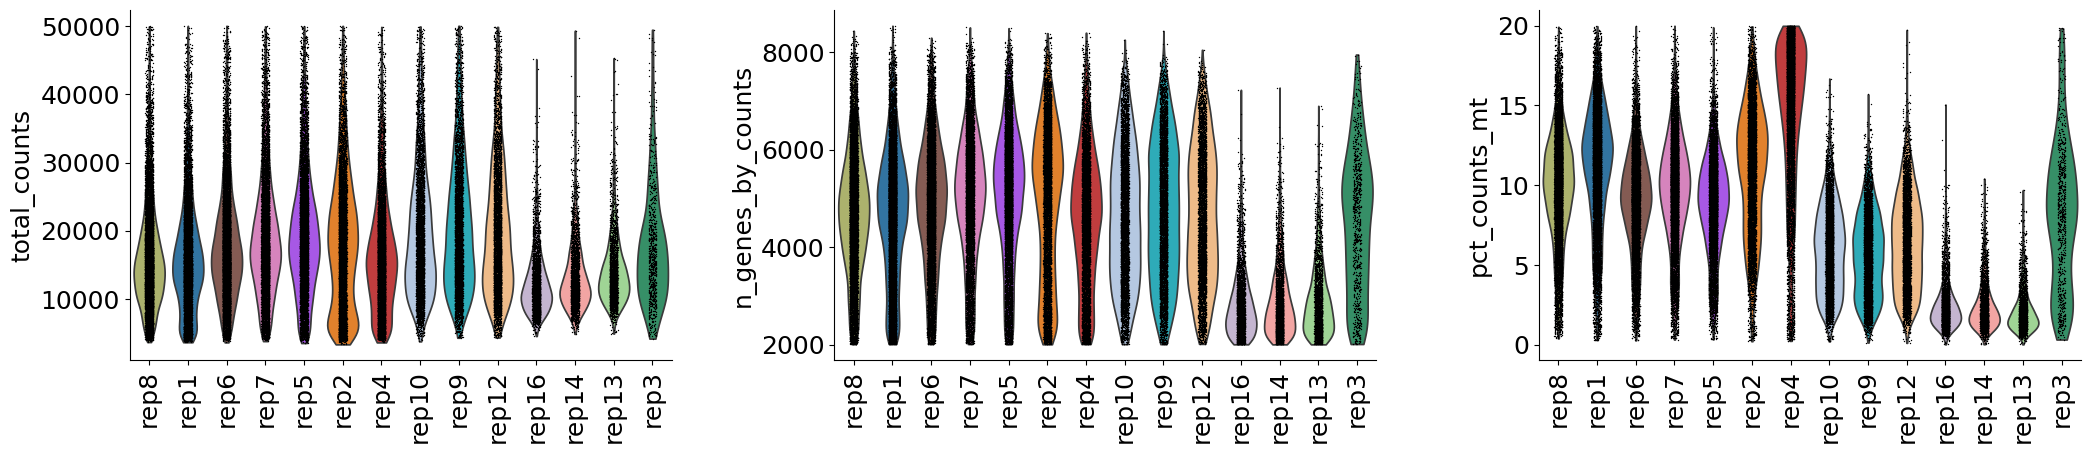

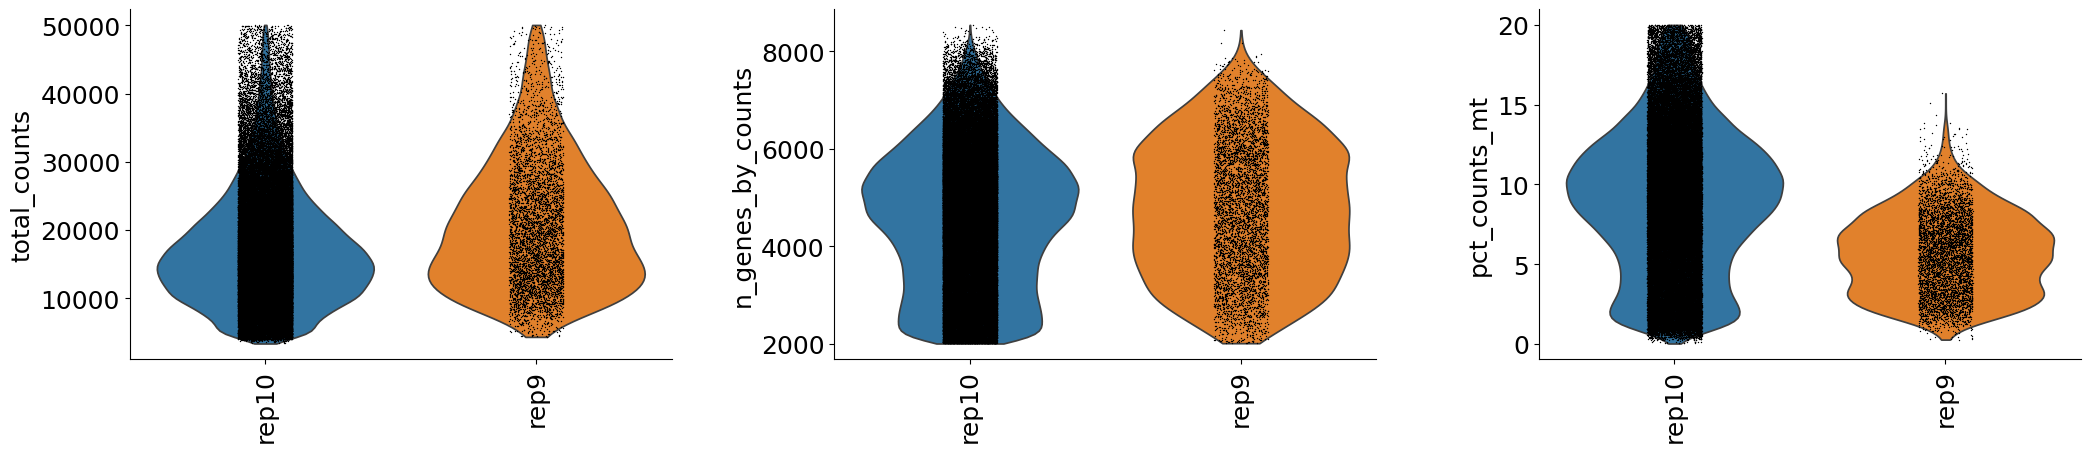

In [ ]:
# plot nCount_RNA per perturbation
sc.pl.violin(
    adata_tf_pert, keys=['total_counts', 'n_genes_by_counts', 'pct_counts_mt'], 
    groupby='replicate',
    rotation=90,
    # log=True, scale='width',
    order=adata_tf_pert.obs['replicate'].value_counts().index,
    show=False,
    # figsize=(12, 6)
)
plt.savefig(f'{res_dir}/violin_nCount_nFeature_RNA_by_replicate.pdf', dpi=300, bbox_inches='tight')
# plot nCount_RNA per perturbation
sc.pl.violin(
    adata_tf_pert, keys=['total_counts', 'n_genes_by_counts', 'pct_counts_mt'], 
    groupby='batch',
    rotation=90,
    # log=True, scale='width',
    order=adata_tf_pert.obs['batch'].value_counts().index,
    show=False,
    # figsize=(12, 6)
)
plt.savefig(f'{res_dir}/violin_qc_metrics_by_batch.pdf', dpi=300, bbox_inches='tight')

[<Axes: title={'center': 'target'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'new_CellType'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'batch'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'replicate'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Timepoint'}, xlabel='UMAP1', ylabel='UMAP2'>]

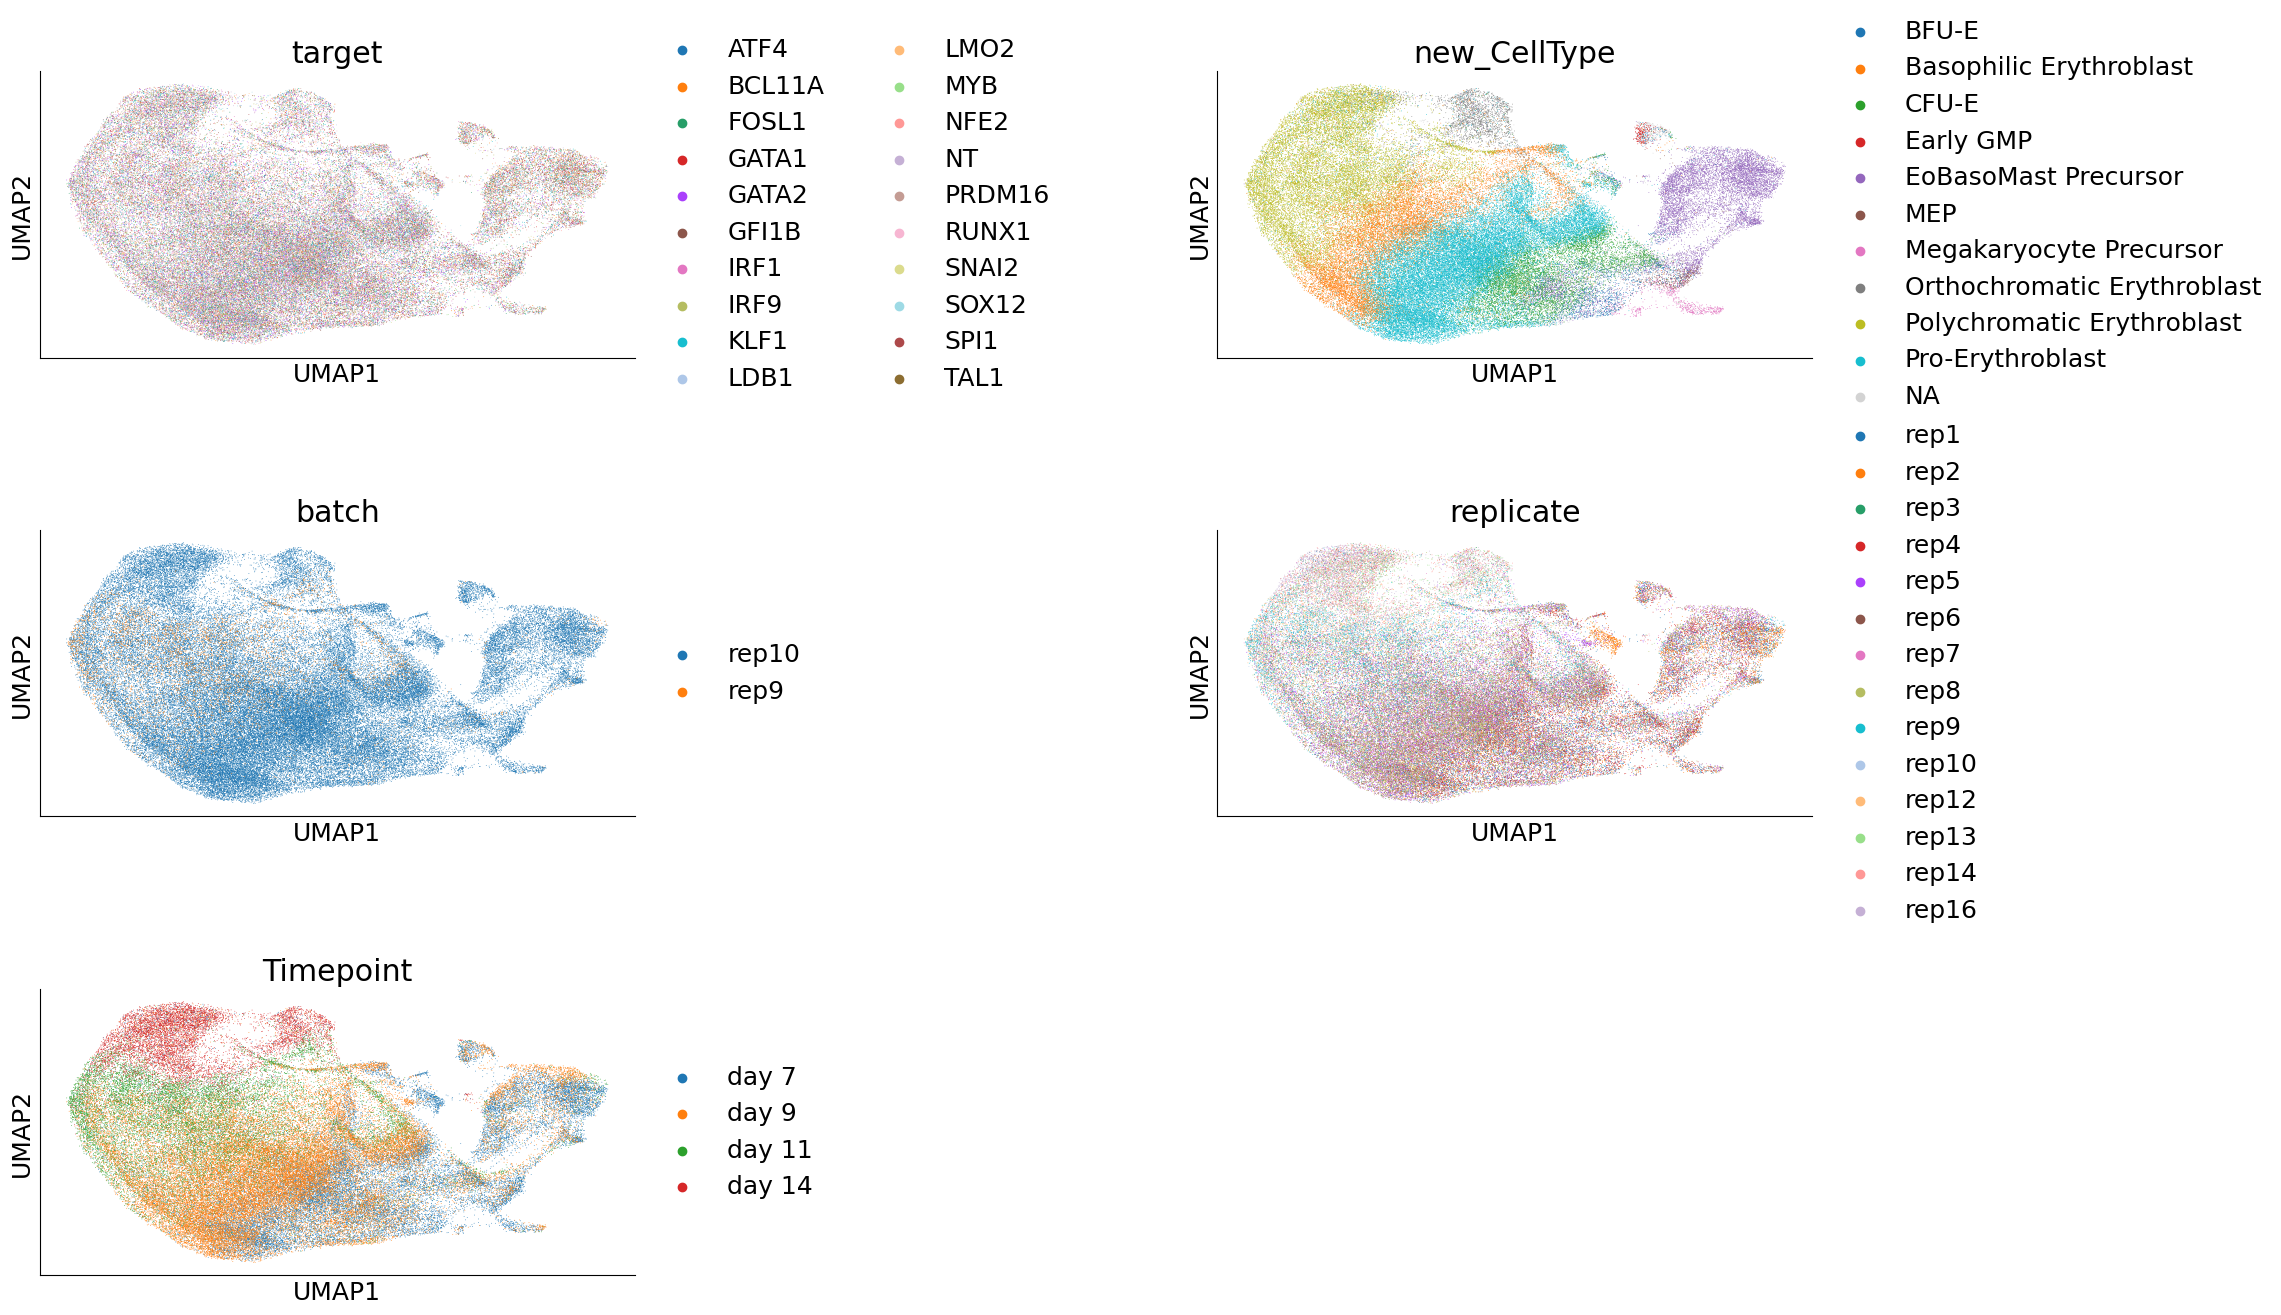

In [ ]:
# plot umap and PCA of the data

sc.pl.umap(adata_tf_pert, color=['target', 'new_CellType', 'batch', 'replicate', 'Timepoint'], wspace=0.8, hspace=0.6, show=False, ncols=2)
plt.savefig(f'{res_dir}/umap_qc_check.pdf', dpi=300, bbox_inches='tight')

[<Axes: title={'center': 'target'}, xlabel='PC1', ylabel='PC2'>,
 <Axes: title={'center': 'new_CellType'}, xlabel='PC1', ylabel='PC2'>,
 <Axes: title={'center': 'batch'}, xlabel='PC1', ylabel='PC2'>,
 <Axes: title={'center': 'replicate'}, xlabel='PC1', ylabel='PC2'>,
 <Axes: title={'center': 'Timepoint'}, xlabel='PC1', ylabel='PC2'>]

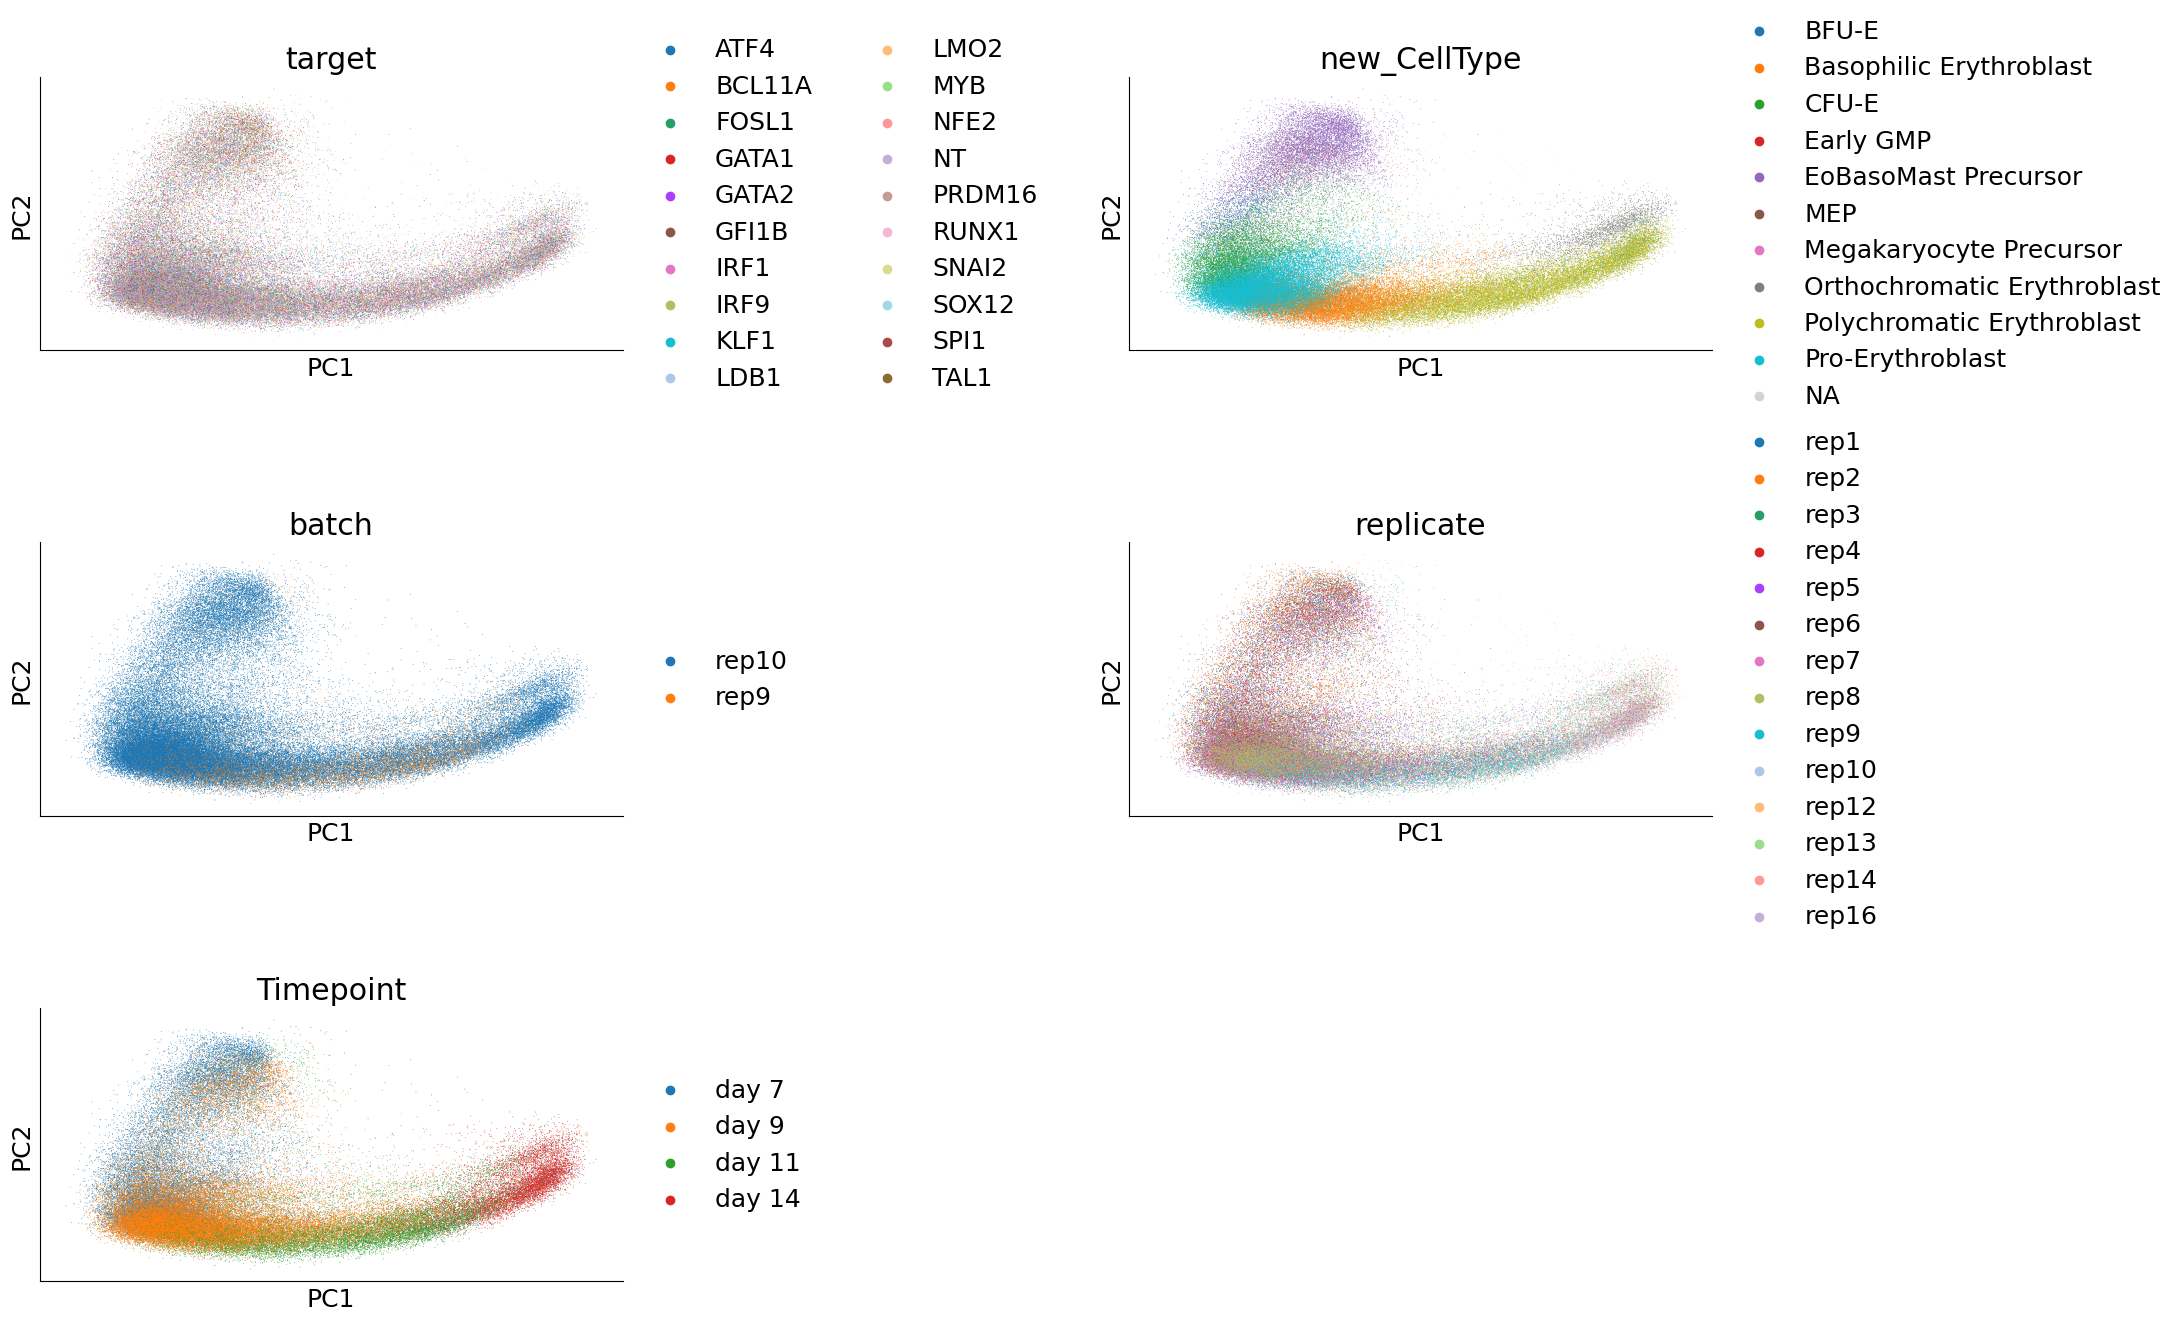

In [ ]:
sc.pl.pca(
    adata_tf_pert, color=['target', 'new_CellType', 'batch', 'replicate', 'Timepoint'], wspace=0.7, hspace=0.7,
    ncols=2,
    show=False,
    components=['1,2']
)
plt.savefig(f'{res_dir}/pca_qc_pc_12.pdf', dpi=300, bbox_inches='tight')

[<Axes: title={'center': 'target'}, xlabel='PC3', ylabel='PC4'>,
 <Axes: title={'center': 'new_CellType'}, xlabel='PC3', ylabel='PC4'>,
 <Axes: title={'center': 'batch'}, xlabel='PC3', ylabel='PC4'>,
 <Axes: title={'center': 'replicate'}, xlabel='PC3', ylabel='PC4'>,
 <Axes: title={'center': 'Timepoint'}, xlabel='PC3', ylabel='PC4'>]

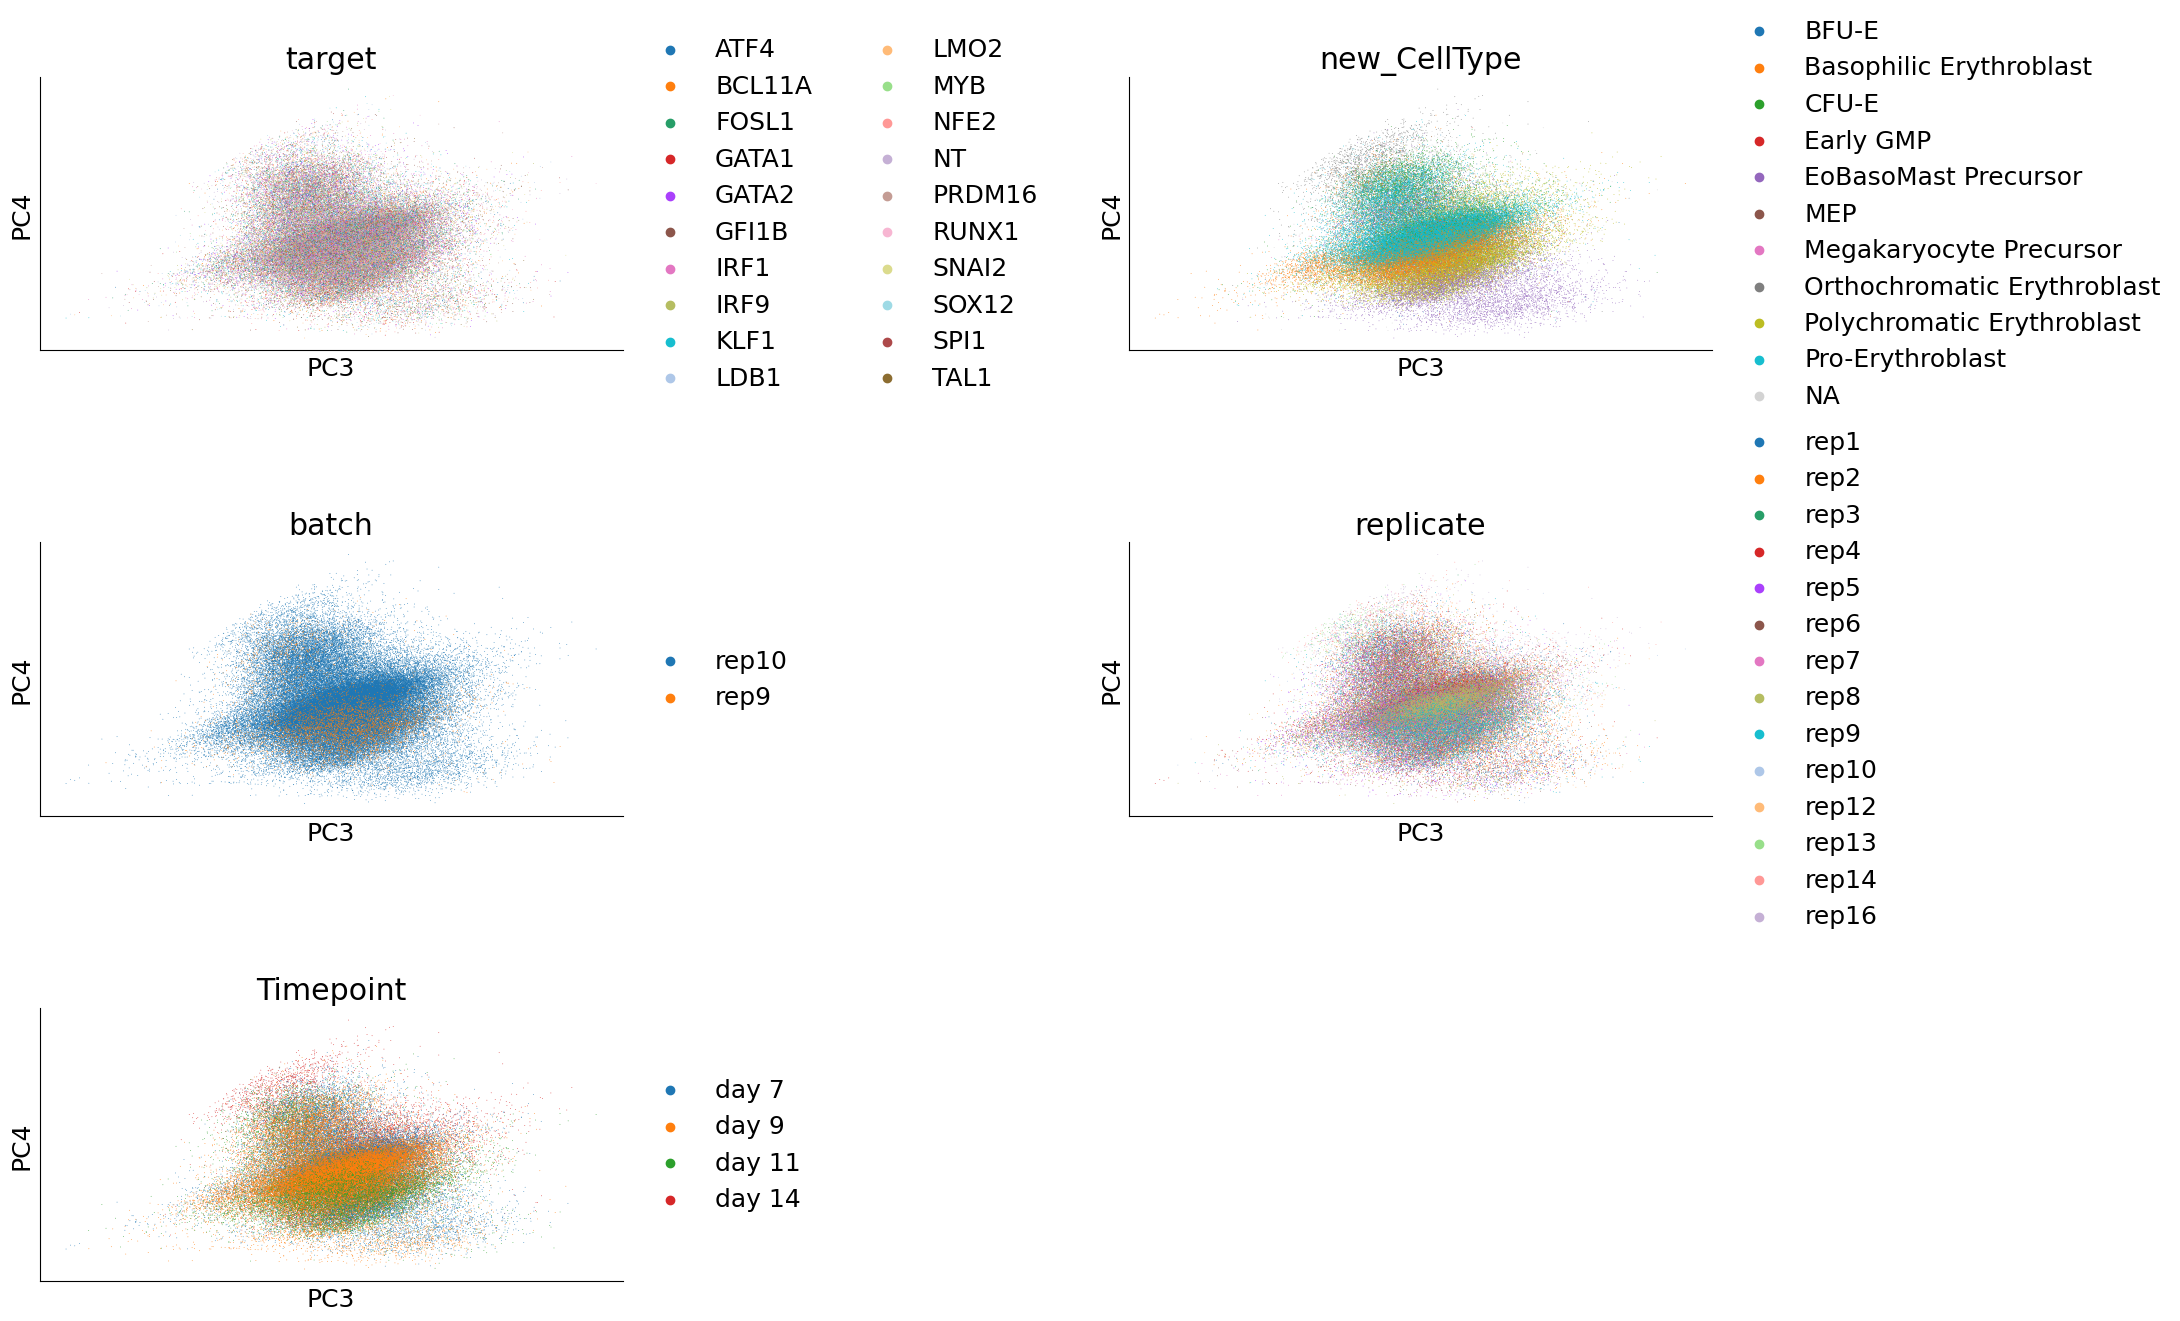

In [ ]:
sc.pl.pca(
    adata_tf_pert, color=['target', 'new_CellType', 'batch', 'replicate', 'Timepoint'], wspace=0.7, hspace=0.7,
    ncols=2,
    show=False,
    components=['3,4']
)
plt.savefig(f'{res_dir}/pca_qc_pc_34.pdf', dpi=300, bbox_inches='tight')

In [28]:
# filter for perturb_name starting with 'NT' and 'AAVS1'
adata_ctrl_guides = adata_tf_pert[adata_tf_pert.obs['perturbation_name'].str.startswith(('NT', 'AAVS1'))]

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


[<Axes: title={'center': 'perturbation_name'}, xlabel='PC1', ylabel='PC2'>,
 <Axes: title={'center': 'perturbation_name'}, xlabel='PC2', ylabel='PC3'>,
 <Axes: title={'center': 'perturbation_name'}, xlabel='PC3', ylabel='PC4'>]

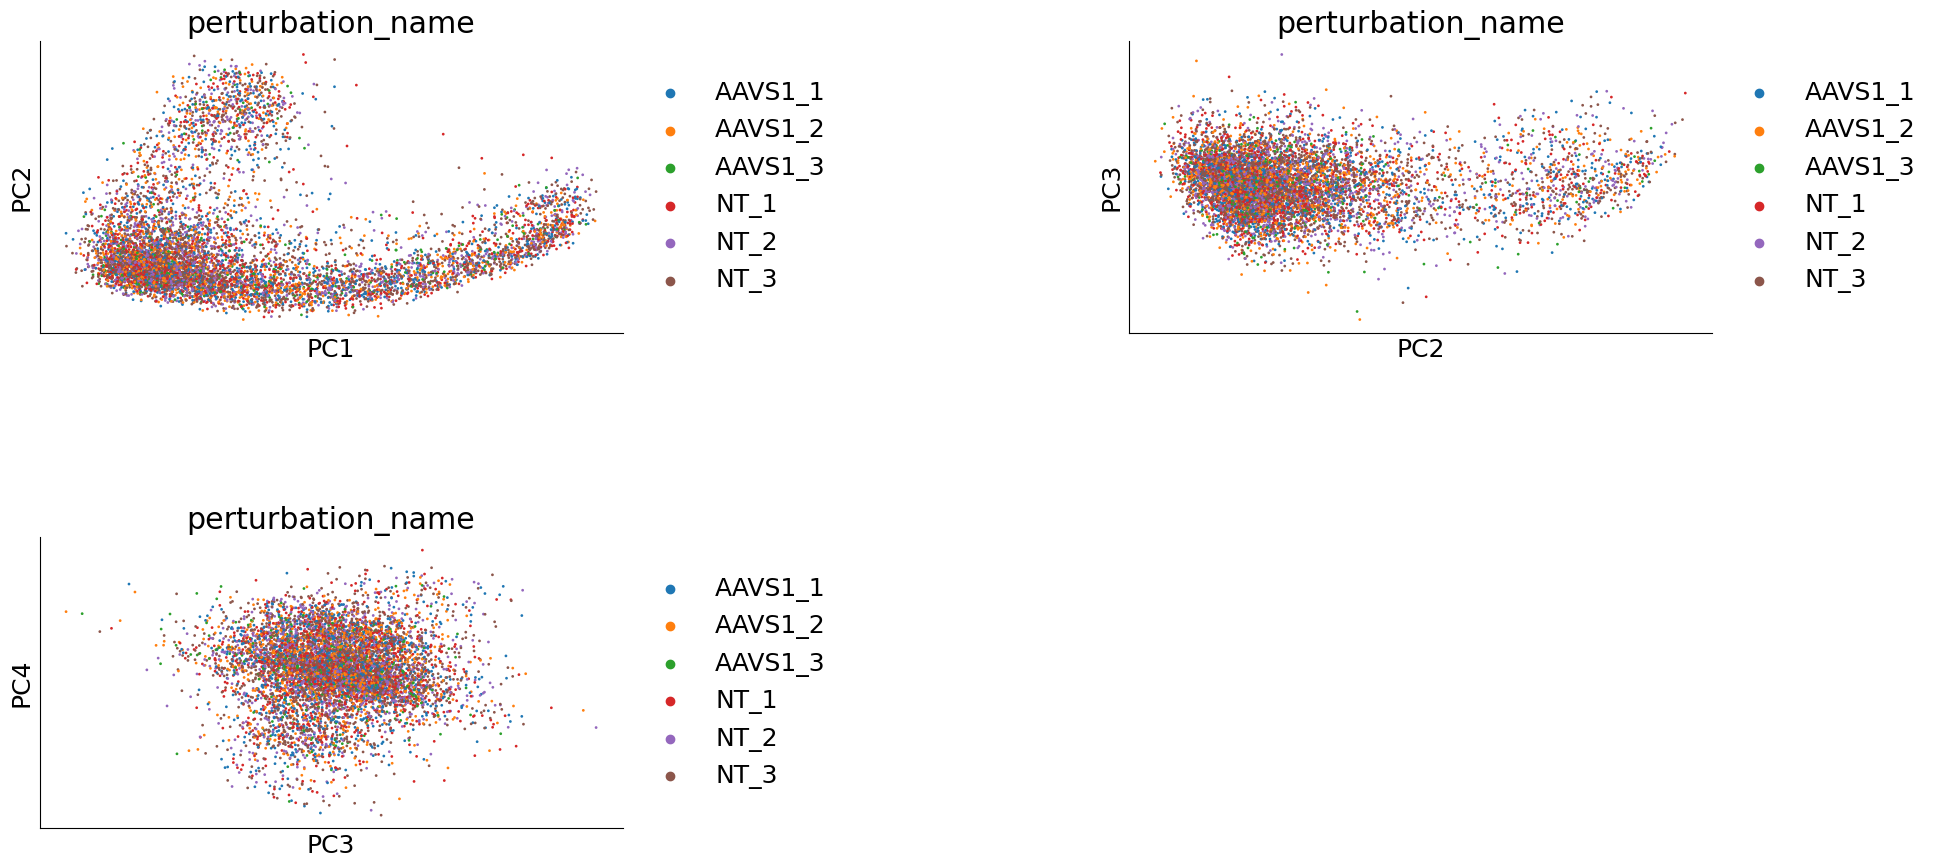

In [ ]:
# plot PCA of control guides
sc.pp.pca(adata_ctrl_guides, n_comps=50)
sc.pl.pca(
    adata_ctrl_guides, color=['perturbation_name'], wspace=0.7, hspace=0.7,
    ncols=2,
    show=False,
    components=['1,2', '2,3', '3,4']
)
plt.savefig(f'{res_dir}/pca_control_guides.pdf', dpi=300, bbox_inches='tight')

In [30]:
adata_tf_pert.obs['new_CellType']

AAACAGCCAATATAGG-1                           NaN
AAACAGCCACAGCCAT-1    Polychromatic Erythroblast
AAACAGCCATAATGAG-1    Polychromatic Erythroblast
AAACATGCAACTGGGA-1    Polychromatic Erythroblast
AAACATGCAAGTCGCT-1    Polychromatic Erythroblast
                                 ...            
TTTGTTGGTAGGTTAT-1    Polychromatic Erythroblast
TTTGTTGGTCATCATC-1    Polychromatic Erythroblast
TTTGTTGGTGTCACGG-1    Polychromatic Erythroblast
TTTGTTGGTGTGTGGT-1    Polychromatic Erythroblast
TTTGTTGGTTCTTTAG-1    Polychromatic Erythroblast
Name: new_CellType, Length: 92286, dtype: category
Categories (10, object): ['BFU-E', 'Basophilic Erythroblast', 'CFU-E', 'Early GMP', ..., 'Megakaryocyte Precursor', 'Orthochromatic Erythroblast', 'Polychromatic Erythroblast', 'Pro-Erythroblast']

/tmp/ipykernel_851836/833348042.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(obs['Timepoint']):
/tmp/ipykernel_851836/833348042.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = obs.groupby(['Timepoint', 'new_CellType']).size().unstack(fill_value=0)


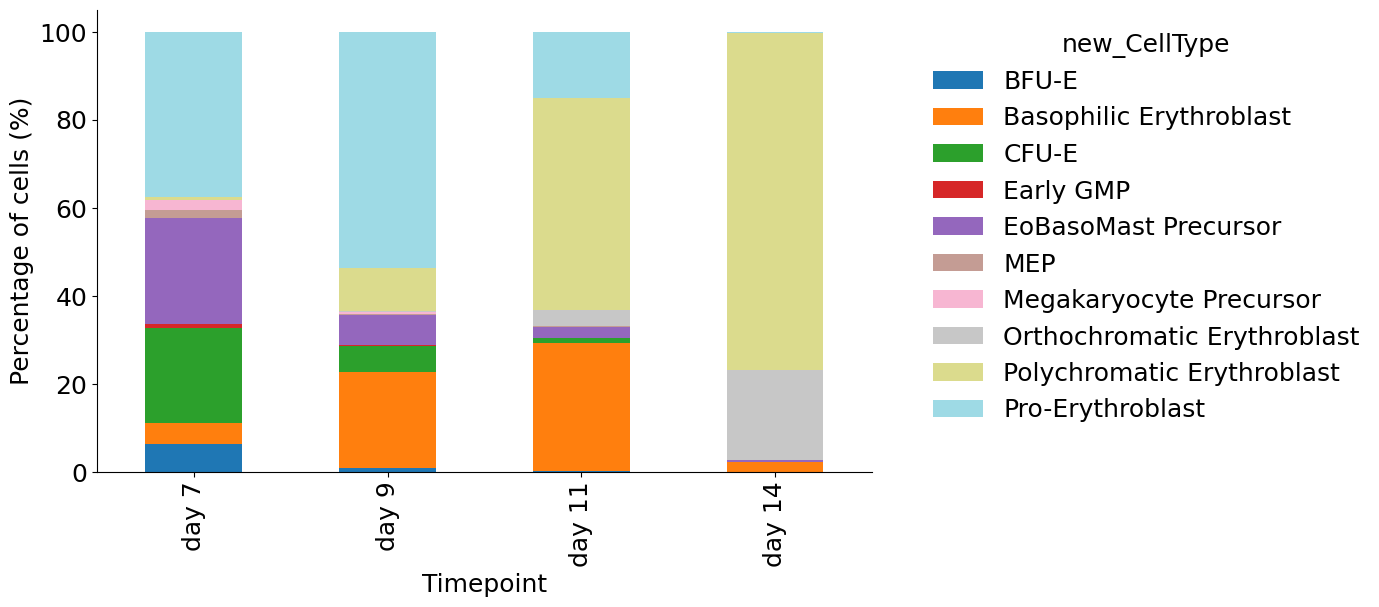

In [31]:
# create stacked percentage barplot for new_CellType by Timepoint
obs = adata_tf_pert.obs.copy()

# determine Timepoint order (respect categorical if present)
if pd.api.types.is_categorical_dtype(obs['Timepoint']):
    tp_order = list(obs['Timepoint'].cat.categories)
else:
    tp_order = sorted(obs['Timepoint'].unique(), key=lambda x: str(x))

# compute counts and convert to percentages per Timepoint
counts = obs.groupby(['Timepoint', 'new_CellType']).size().unstack(fill_value=0)
counts = counts.reindex(tp_order).fillna(0)
prop = counts.div(counts.sum(axis=1), axis=0) * 100

# plot stacked barplot
ax = prop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
ax.set_ylabel('Percentage of cells (%)')
ax.set_xlabel('Timepoint')
# ax.set_title('Distribution of new_CellType across Timepoints')
ax.legend(title='new_CellType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(f'{res_dir}/stacked_bar_new_CellType_by_Timepoint.pdf', dpi=300, bbox_inches='tight')


/tmp/ipykernel_851836/3040000168.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(obs['Timepoint']):
/tmp/ipykernel_851836/3040000168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = obs.groupby(['Timepoint', 'target']).size().unstack(fill_value=0)


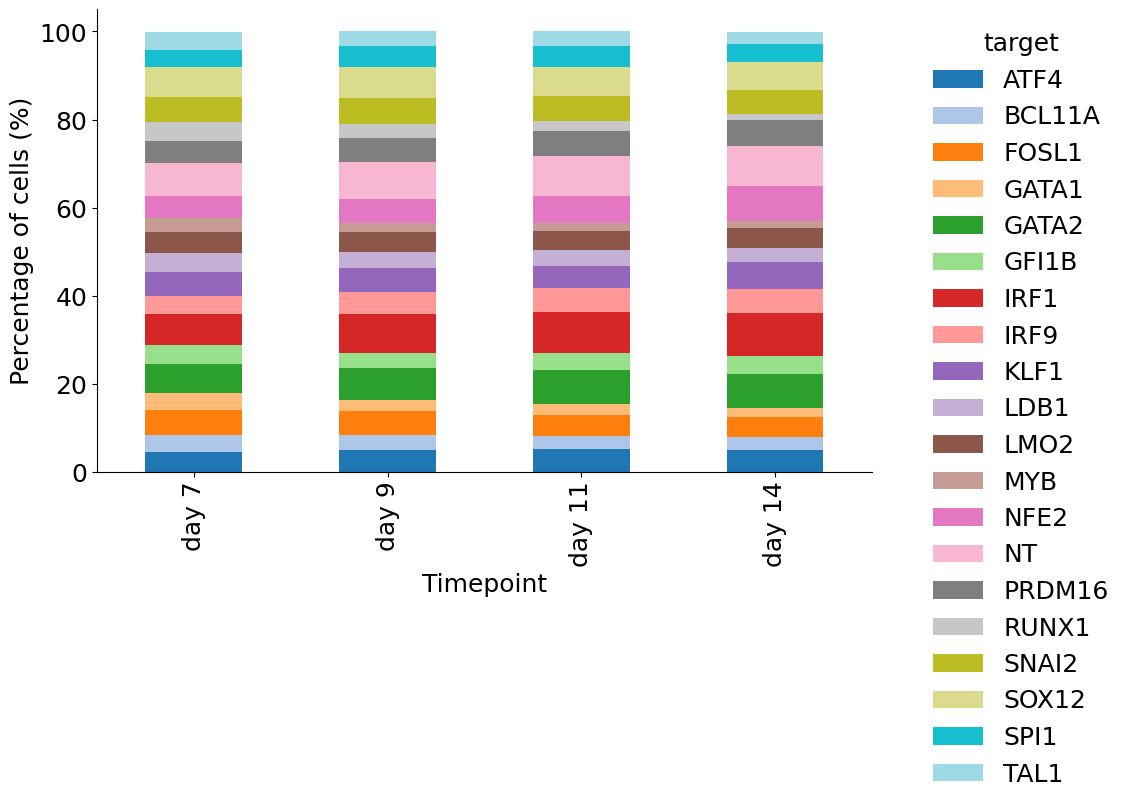

In [32]:
# create stacked percentage barplot for new_CellType by Timepoint
obs = adata_tf_pert.obs.copy()

# determine Timepoint order (respect categorical if present)
if pd.api.types.is_categorical_dtype(obs['Timepoint']):
    tp_order = list(obs['Timepoint'].cat.categories)
else:
    tp_order = sorted(obs['Timepoint'].unique(), key=lambda x: str(x))

# compute counts and convert to percentages per Timepoint
counts = obs.groupby(['Timepoint', 'target']).size().unstack(fill_value=0)
counts = counts.reindex(tp_order).fillna(0)
prop = counts.div(counts.sum(axis=1), axis=0) * 100

# plot stacked barplot
ax = prop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
ax.set_ylabel('Percentage of cells (%)')
ax.set_xlabel('Timepoint')
# ax.set_title('Distribution of new_CellType across Timepoints')
ax.legend(title='target', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
plt.savefig(f'{res_dir}/stacked_bar_target_by_Timepoint.pdf', dpi=300, bbox_inches='tight')


In [33]:
adata_tf_pert.obs

,batch,perturbation,replicate,Timepoint,nCount_RNA,nFeature_RNA,nCount_atac,nFeature_atac,perturbation_name,target,...,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,n_genes
AAACAGCCAATATAGG-1,rep10,AGAAATACGGTCCGAAACGT,rep8,day 9,3282.0,1692.0,18117.0,8288.0,MYB_339,MYB,...,9.229260,46.771344,53.424926,61.491658,73.326791,118.0,4.779123,1.157998,10179.0,2517
AAACAGCCACAGCCAT-1,rep10,TGTGGTCGCAGCACGAACGG,rep10,day 11,14155.0,4083.0,30043.0,12015.0,SOX12_162,SOX12,...,9.557894,28.618863,38.036030,46.499470,58.226775,908.0,6.812345,6.414694,14144.0,4072
AAACAGCCATAATGAG-1,rep10,TCTAGGCCGATACAAAGCAG,rep10,day 11,18836.0,4691.0,19324.0,8454.0,IRF1_199,IRF1,...,9.843578,27.893396,35.840943,44.383096,56.822043,1247.0,7.129298,6.620301,18818.0,4673
AAACATGCAACTGGGA-1,rep10,GGGGCCACTAGGGACAGGAT,rep10,day 11,10678.0,3397.0,7498.0,3686.0,AAVS1_1,NT,...,9.276034,29.003559,36.935756,45.785728,59.542986,406.0,6.008813,3.802210,10659.0,3378
AAACATGCAAGTCGCT-1,rep10,TGTGGTCGCAGCACGAACGG,rep10,day 11,23310.0,4391.0,32862.0,12379.0,SOX12_162,SOX12,...,10.056681,42.432432,50.051480,58.116688,68.386958,687.0,6.533789,2.947233,23284.0,4367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTAGGTTAT-1,rep9,AAGGCGCGAGCGGAACAAGC,rep9,day 11,9823.0,3388.0,30268.0,11385.0,FOSL1_346,FOSL1,...,9.192584,25.328311,32.546065,41.647155,56.296447,469.0,6.152733,4.774508,9812.0,3378
TTTGTTGGTCATCATC-1,rep9,ACTGTATGGAGGGGATCCCA,rep9,day 11,8561.0,2782.0,26648.0,10738.0,GATA1_261,GATA1,...,9.055089,33.734377,42.004439,51.022077,64.338278,219.0,5.393628,2.558112,8553.0,2774
TTTGTTGGTGTCACGG-1,rep9,GGAGAAGATCCCGTTCGTGC,rep9,day 11,12739.0,4138.0,35195.0,13658.0,SOX12_268,SOX12,...,9.452502,28.189026,34.798650,42.522961,54.902269,883.0,6.784457,6.931470,12719.0,4118
TTTGTTGGTGTGTGGT-1,rep9,CAGCCGCCGGCACATAGGAG,rep9,day 11,9536.0,2879.0,42042.0,13691.0,GATA2_752,GATA2,...,9.162934,34.836409,41.359060,50.157299,64.303691,212.0,5.361292,2.223154,9520.0,2865


/tmp/ipykernel_851836/2092721597.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['target', 'replicate'])


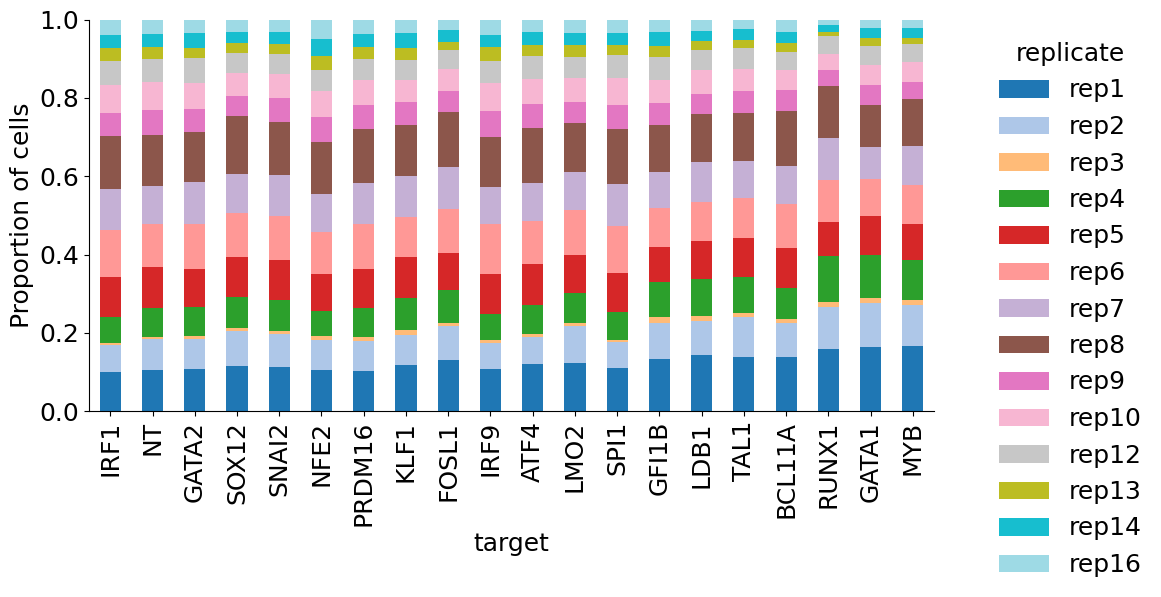

In [34]:
# plot replicate per target barplot distribution
plot_df = (
    adata_tf_pert.obs[['target', 'replicate']]
    .groupby(['target', 'replicate'])
    .size()
    .reset_index(name='count')
)
plot_df = plot_df.pivot(index='target', columns='replicate', values='count').fillna(0)
plot_df = plot_df.loc[plot_df.sum(axis=1).sort_values(ascending=False).index]

# normalize rows to sum to 1 to compare distributions
plot_df_norm = plot_df.div(plot_df.sum(axis=1), axis=0)

ax = plot_df_norm.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
ax.set_ylabel('Proportion of cells')
ax.set_xlabel('target')
ax.set_ylim(0, 1)
ax.legend(title='replicate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{res_dir}/replicate_distribution_normalized_by_target.pdf', dpi=300, bbox_inches='tight')


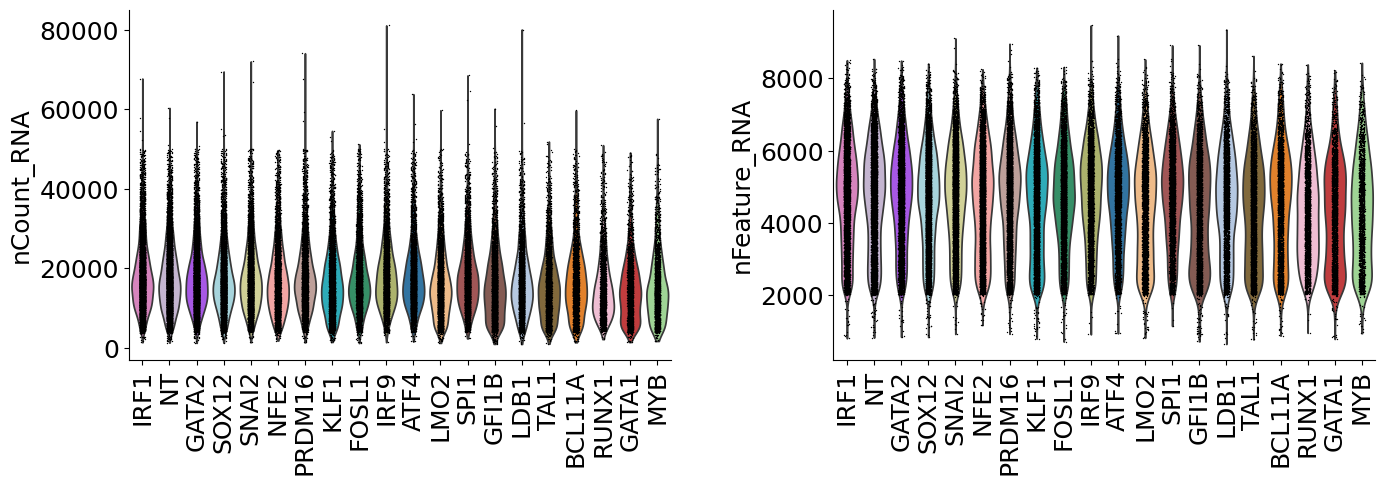

In [35]:
# plot nCount_RNA per perturbation
sc.pl.violin(
    adata_tf_pert, keys=['nCount_RNA', 'nFeature_RNA'], 
    groupby='target',
    rotation=90,
    # log=True, scale='width',
    order=adata_tf_pert.obs['target'].value_counts().index,
    show=False,
    # figsize=(12, 6)
)
plt.savefig(f'{res_dir}/violin_nCount_RNA_by_target.pdf', dpi=300, bbox_inches='tight')

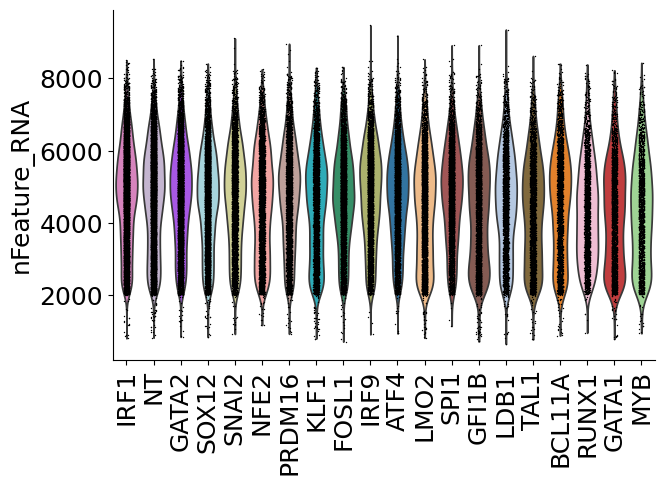

In [36]:
# plot nCount_RNA per perturbation
sc.pl.violin(
    adata_tf_pert, keys='nFeature_RNA', 
    groupby='target',
    rotation=90,
    # log=True, scale='width',
    order=adata_tf_pert.obs['target'].value_counts().index,
    show=False,
    # figsize=(12, 6)
)
plt.savefig(f'{res_dir}/violin_nFeature_RNA_by_target.pdf', dpi=300, bbox_inches='tight')

#### 2. EMD calculation

In [37]:
adata_tf_pert.obs['celltype_v2'] = adata_tf_pert.obs['new_CellType'].astype('category')

In [38]:
adata_tf_pert.var

,gene_ids,feature_types,genome,interval,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_counts,n_cells
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723,False,2677,0.023824,0.023545,97.726327,2805.0,7.939515,2750.0,2622
AL627309.5,ENSG00000241860,Gene Expression,GRCh38,chr1:149706-173862,False,2859,0.025004,0.024697,97.571748,2944.0,7.987864,2866.0,2781
LINC01409,ENSG00000237491,Gene Expression,GRCh38,chr1:778757-803934,False,15030,0.148082,0.138093,87.234476,17435.0,9.766293,16809.0,14482
LINC01128,ENSG00000228794,Gene Expression,GRCh38,chr1:827597-860227,False,28252,0.309413,0.269579,76.004552,36430.0,10.503176,35337.0,27354
LINC00115,ENSG00000225880,Gene Expression,GRCh38,chr1:827521-827522,False,2001,0.017437,0.017287,98.300478,2053.0,7.627544,1991.0,1940
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC011043.1,ENSG00000276256,Gene Expression,GRCh38,GL000195.1:49163-49164,False,12178,0.121098,0.114309,89.656783,14258.0,9.565144,13571.0,11587
AL354822.1,ENSG00000278384,Gene Expression,GRCh38,GL000218.1:54892-54893,False,7163,0.065238,0.063198,93.916204,7681.0,8.946635,7404.0,6900
AL592183.1,ENSG00000273748,Gene Expression,GRCh38,GL000219.1:83310-83311,False,36697,0.440118,0.364725,68.831908,51819.0,10.855532,49875.0,35304
AC240274.1,ENSG00000271254,Gene Expression,GRCh38,KI270711.1:24649-29626,False,1035,0.009105,0.009064,99.120937,1072.0,6.978214,1031.0,995


In [39]:
adata_terminal.var

,gene_name,ensembl_id,token_id,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,row_id
ensembl_id,,,,,,,,,,
ENSG00000187583,PLEKHN1,ENSG00000187583,7,True,0.001372,0.901854,0.389840,2,False,4
ENSG00000187642,PERM1,ENSG00000187642,8,True,0.000339,0.842606,0.791403,2,False,5
ENSG00000188290,HES4,ENSG00000188290,9,True,0.092814,1.908872,3.451489,3,True,6
ENSG00000187608,ISG15,ENSG00000187608,10,True,0.669082,1.570766,2.241486,3,True,7
ENSG00000186891,TNFRSF18,ENSG00000186891,14,True,0.058060,1.573518,2.232047,3,True,8
...,...,...,...,...,...,...,...,...,...,...
ENSG00000012817,KDM5D,ENSG00000012817,15230,True,0.157127,1.056631,0.768306,3,True,5699
ENSG00000198692,EIF1AY,ENSG00000198692,15231,True,0.608283,1.219838,0.994824,3,True,5700
ENSG00000274847,MAFIP,ENSG00000274847,14427,True,0.013408,0.973882,0.540665,2,False,5701


In [40]:
adata_tf_pert.var_names

Index(['AL627309.1', 'AL627309.5', 'LINC01409', 'LINC01128', 'LINC00115',
       'FAM41C', 'NOC2L', 'KLHL17', 'ISG15', 'AGRN',
       ...
       'MT-ND5', 'MT-ND6', 'MT-CYB', 'BX004987.1', 'MAFIP', 'AC011043.1',
       'AL354822.1', 'AL592183.1', 'AC240274.1', 'AC007325.4'],
      dtype='object', length=15662)

In [41]:
adata_tf_pert = adata_tf_pert[:, adata_tf_pert.var_names.isin(adata_terminal.var.gene_name)]
adata_terminal = adata_terminal[:, adata_terminal.var.gene_name.isin(adata_tf_pert.var_names)]



In [42]:
adata_terminal.obs.celltype_v2.value_counts()

celltype_v2
Pro_B            10958
Early_Ery        10660
Large_Pre_B       3335
Cycling_Pro_B     3192
Mono_pre          2746
Late_Ery          2603
pDC               2170
DC_pre            2124
MK                1669
BaEoMa            1609
Immature_B         960
Macrophage         880
Small_Pre_B        658
PreProB            456
Name: count, dtype: int64

In [43]:
adata_terminal.obs['celltype_v2'] = (
    adata_terminal.obs['celltype_v2']
    .replace({
        'Small_Pre_B': 'Pre_B',
        'Immature_B': 'Pre_B',
        'Large_Pre_B': 'Cycling_Pro_B',
    })
    .astype('category')
)

/tmp/ipykernel_851836/1763743080.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({
/tmp/ipykernel_851836/1763743080.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_terminal.obs['celltype_v2'] = (


In [44]:
adata_terminal.X.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.8196926 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.9689059 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.06257567, 0.06257567, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(44020, 3921), dtype=float32)

In [45]:
adata_terminal.obs['celltype_v2'] = adata_terminal.obs['celltype_v2'].cat.reorder_categories(
    [
        'PreProB', 'Cycling_Pro_B','Pre_B', 'Pro_B', 'pDC', 
        'MK', 'Early_Ery', 'Late_Ery', 'BaEoMa',
        'DC_pre', 'Mono_pre', 'Macrophage']
    )

In [46]:
adata_ctrl = adata_tf_pert[adata_tf_pert.obs['target'] == 'NT']
# perform pairwise cell type comparisons
emd_results = {}
for ct in adata_terminal.obs['celltype_v2'].cat.categories:
    for ct_pert in adata_ctrl.obs['celltype_v2'].cat.categories:
        # print(f'Computing EMD for {ct} vs {ct_pert}')
        adata_ct = adata_terminal[adata_terminal.obs.celltype_v2 == ct]
        # print(adata_ct.X)
        # print(f'Original cell type {ct} has {adata_ct.n_obs} cells')
        adata_ct_pert = adata_ctrl[adata_ctrl.obs.celltype_v2 == ct_pert]
        # print(adata_ct_pert.X)
        # print(f'Perturbed cell type {ct_pert} has {adata_ct_pert.n_obs} cells')
        emd = evaluate_emd(adata_ct, adata_ct_pert)
        # print(emd)
        emd_results[(ct, ct_pert)] = emd['emd'][0]
        # raise   

In [47]:
# create a dataframe from the results
emd_df = pd.DataFrame.from_dict(emd_results, orient='index', columns=['emd'])
emd_df.index = pd.MultiIndex.from_tuples(emd_df.index, names=['original_cell_type', 'perturbed_cell_type'])
emd_df = emd_df.reset_index()

In [48]:
emd_df

,original_cell_type,perturbed_cell_type,emd
0,PreProB,BFU-E,0.216657
1,PreProB,Basophilic Erythroblast,0.214836
2,PreProB,CFU-E,0.216496
3,PreProB,Early GMP,0.224199
4,PreProB,EoBasoMast Precursor,0.231818
...,...,...,...
115,Macrophage,MEP,0.263268
116,Macrophage,Megakaryocyte Precursor,0.264013
117,Macrophage,Orthochromatic Erythroblast,0.210160
118,Macrophage,Polychromatic Erythroblast,0.239128


In [49]:
emd_df['original_cell_type'] = emd_df['original_cell_type'].astype('category')

In [50]:
emd_df['original_cell_type'] = emd_df['original_cell_type'].cat.reorder_categories(
    [
        'PreProB', 'Cycling_Pro_B','Pre_B', 'Pro_B', 'pDC', 
        'MK', 'Early_Ery', 'Late_Ery', 'BaEoMa',
        'DC_pre', 'Mono_pre', 'Macrophage']
    )

<Figure size 2000x1500 with 0 Axes>

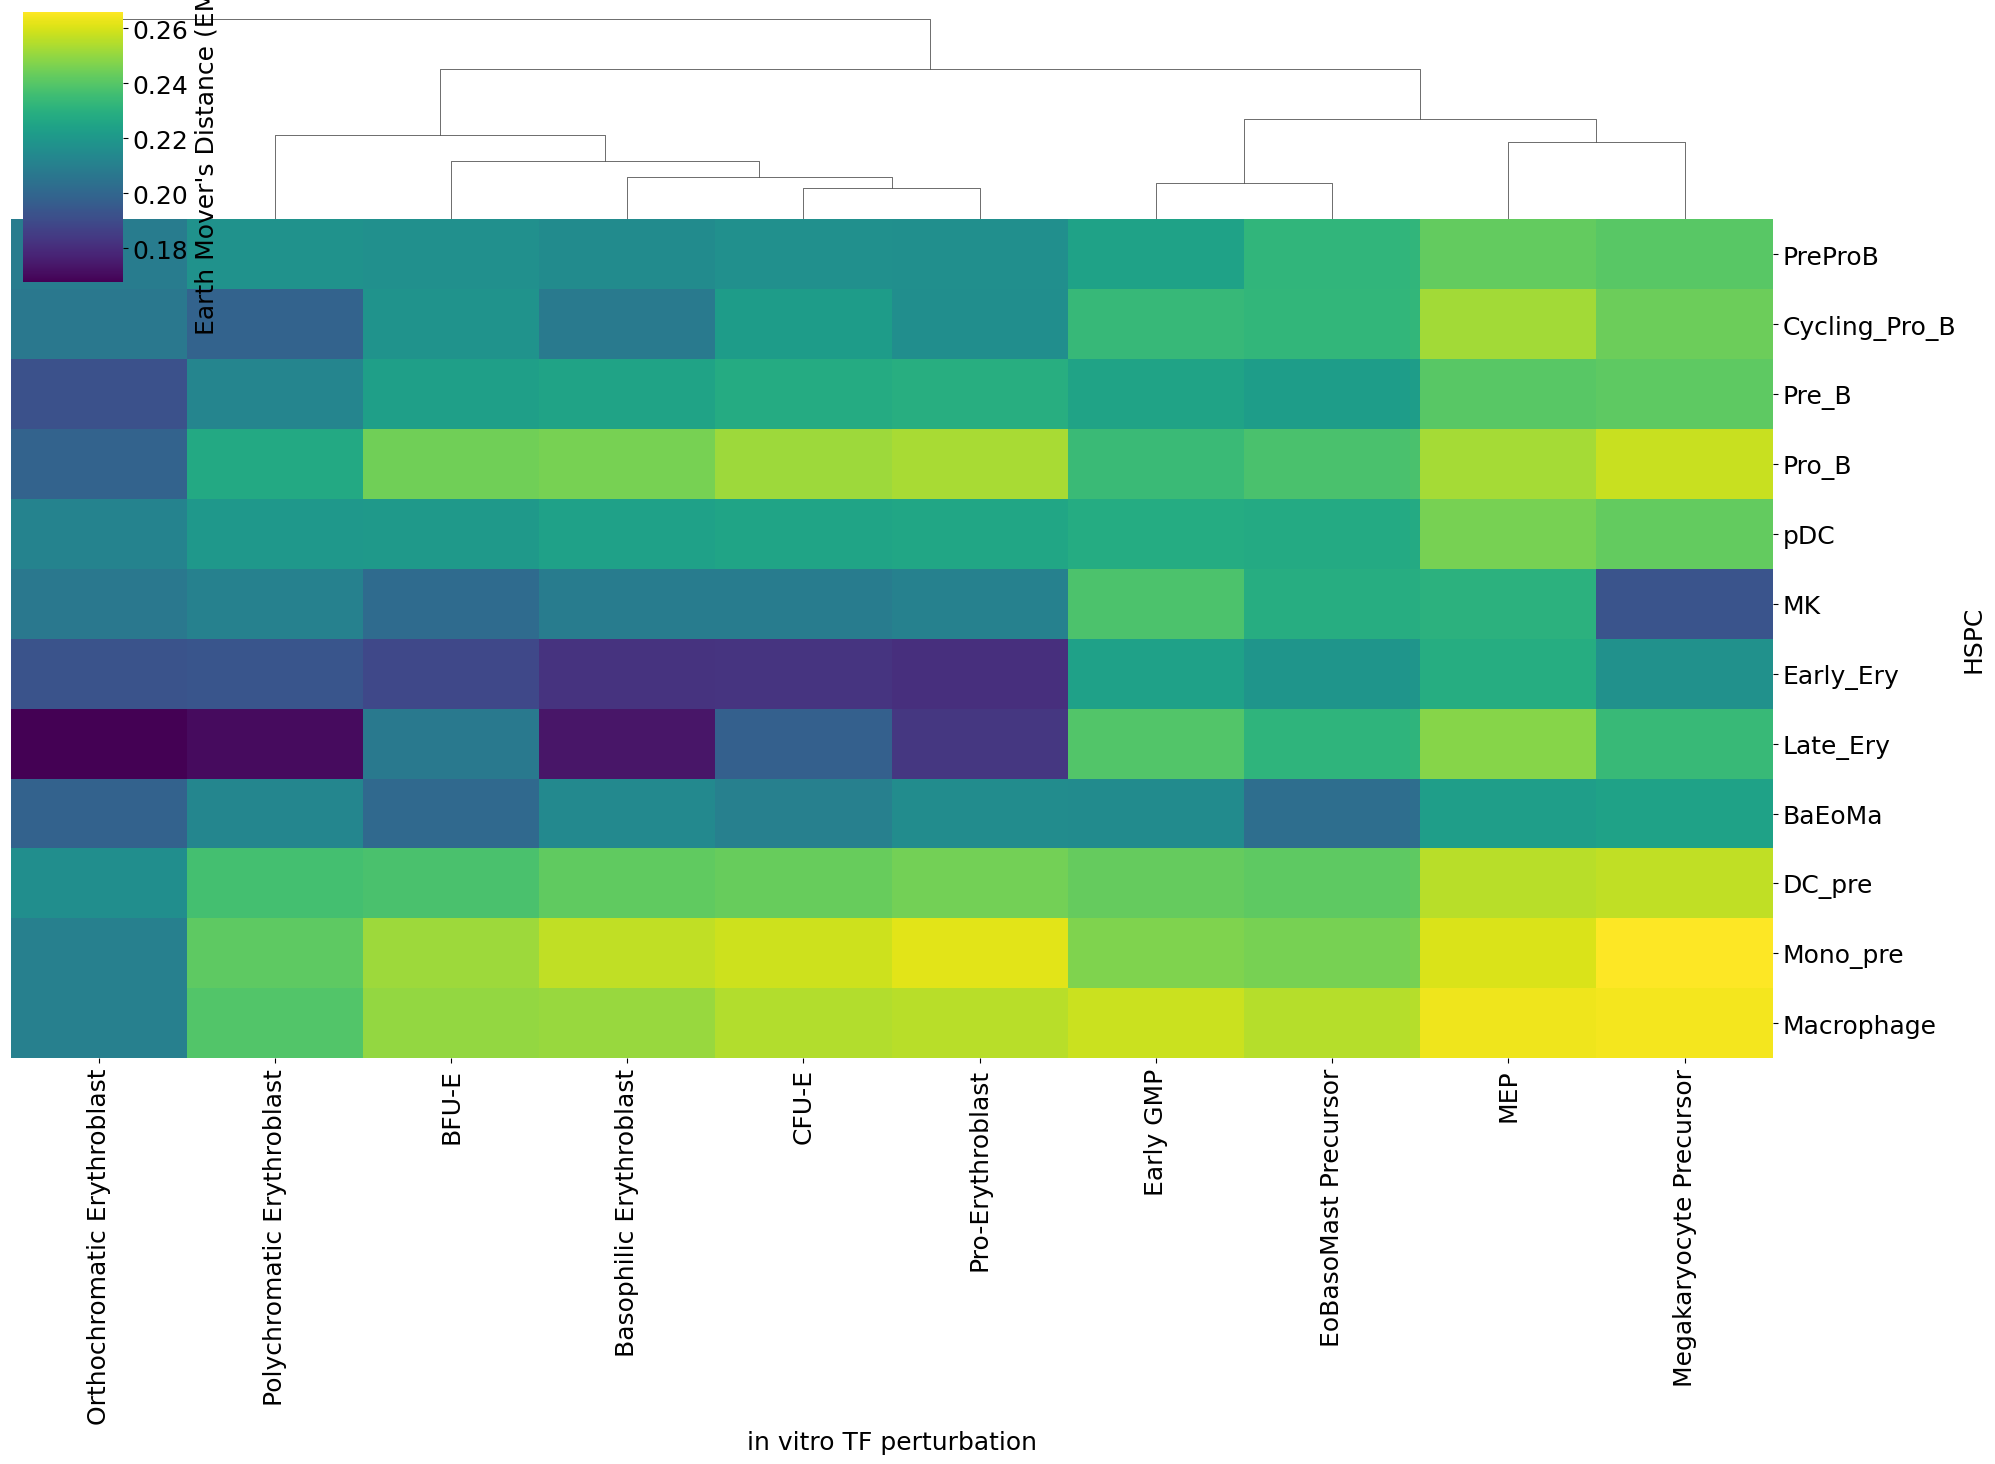

In [51]:
# plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
heatmap_data = emd_df.pivot(
    index='original_cell_type',
    columns='perturbed_cell_type',
    values='emd'
)
row_order = emd_df['original_cell_type'].cat.categories


heatmap_data = heatmap_data.loc[row_order,:]
g = sns.clustermap(
    heatmap_data,
    cmap='viridis',
    annot=False,
    fmt=".2f",
    figsize=(20, 15),
    cbar_kws={'label': "Earth Mover's Distance (EMD)"},
    row_cluster=False,
    col_cluster=True,
    dendrogram_ratio=(0.0, 0.2)  # hide row dendrogram
)

g.ax_heatmap.set_ylabel('HSPC')
g.ax_heatmap.set_xlabel('in vitro TF perturbation')


plt.savefig(f'{res_dir}/emd_heatmap.pdf', dpi=300, bbox_inches='tight')

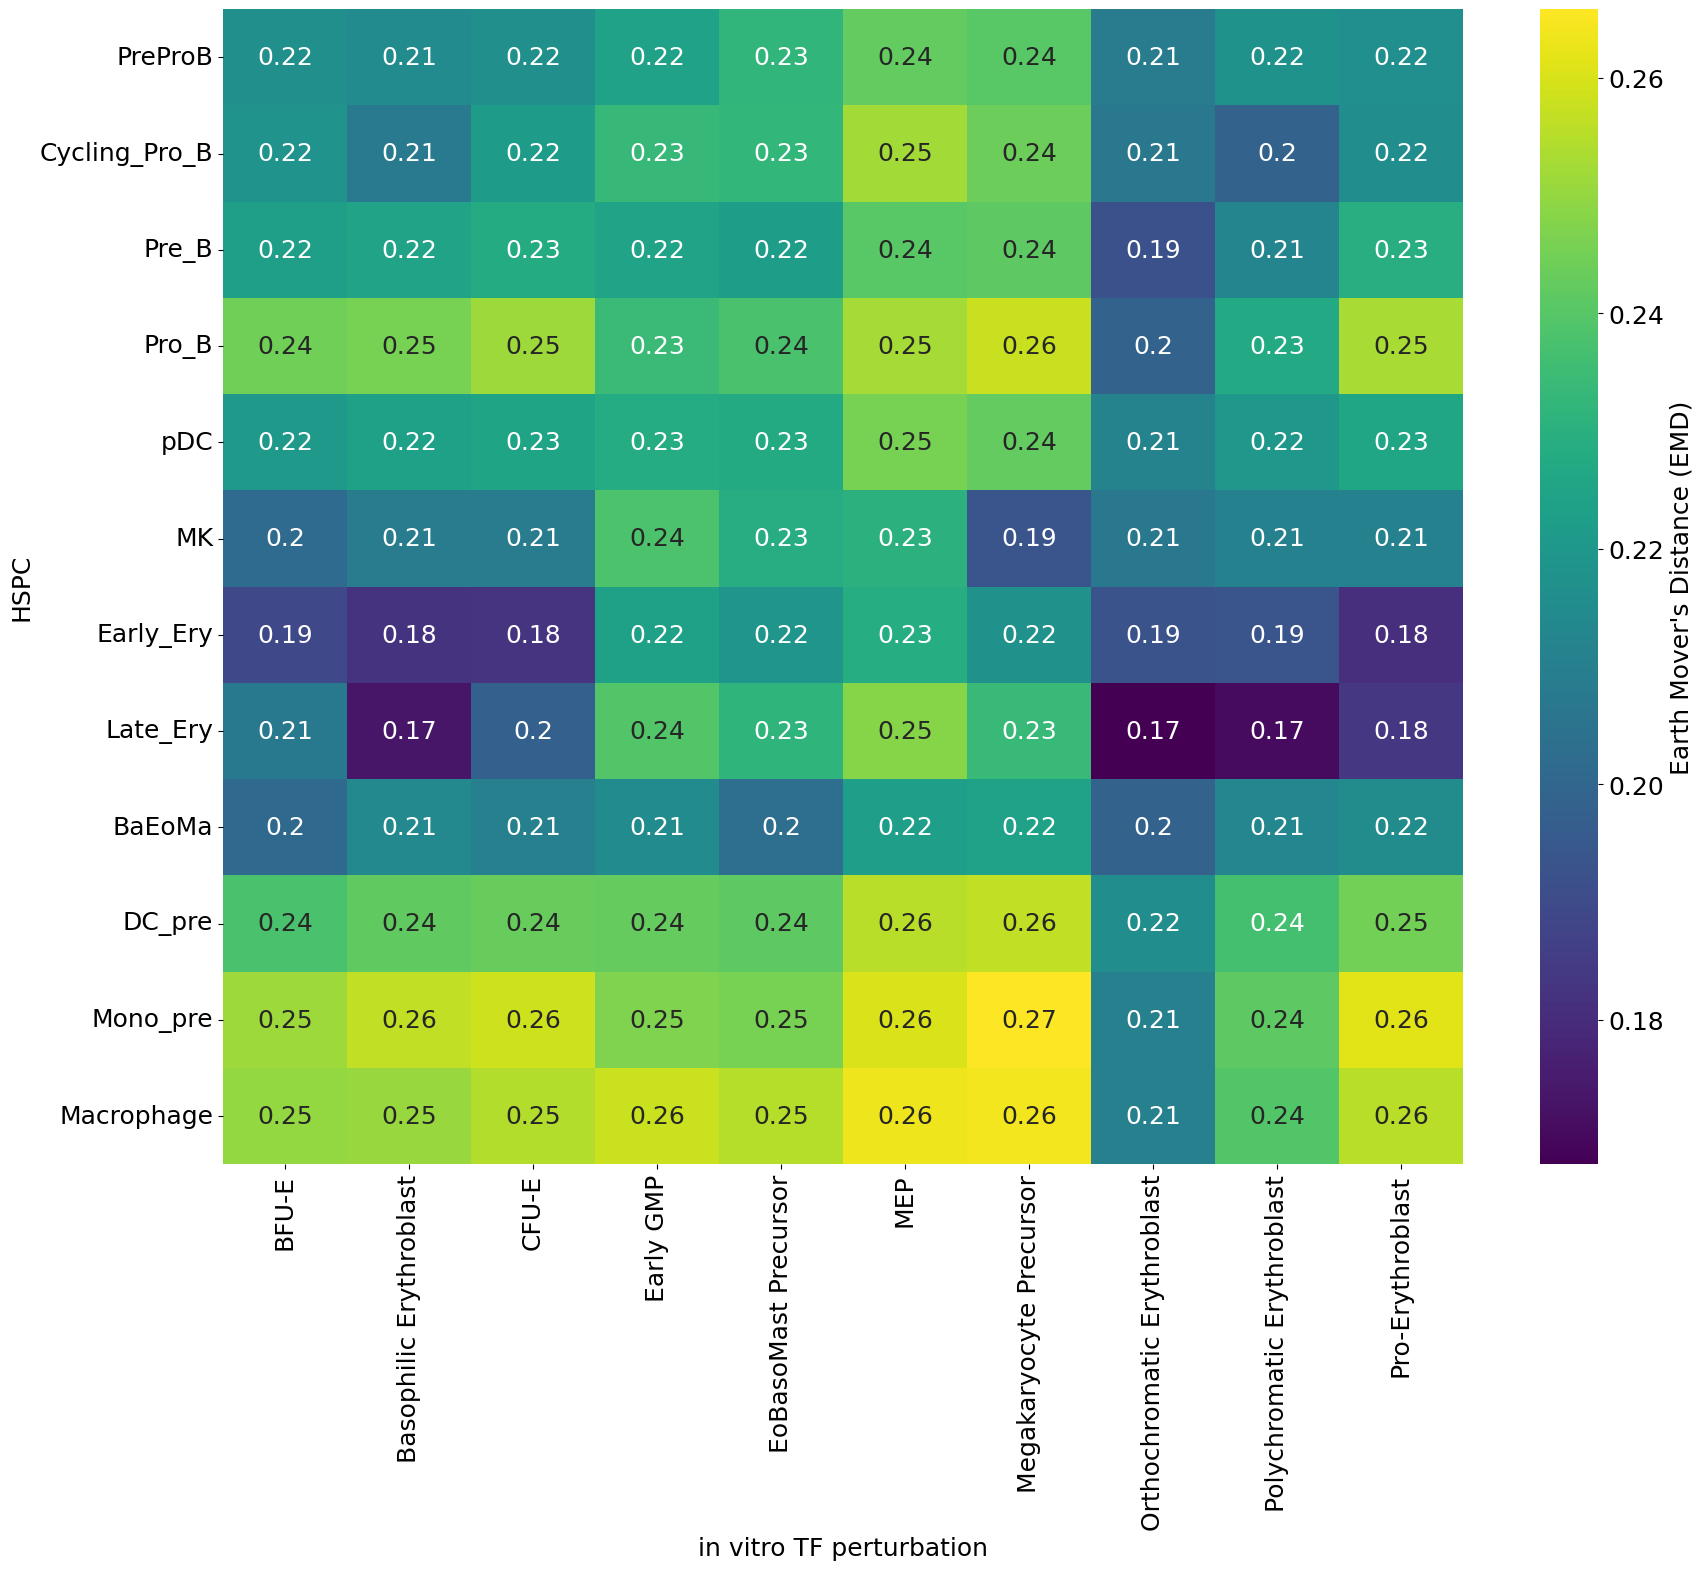

In [52]:
# plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
heatmap_data = emd_df.pivot(
    index='original_cell_type',
    columns='perturbed_cell_type',
    values='emd'
)
ax = sns.heatmap(
    heatmap_data,
    annot=True, 
    cmap='viridis', 
    cbar_kws={'label': "Earth Mover's Distance (EMD)"}
)
plt.ylabel('HSPC')
plt.xlabel('in vitro TF perturbation')


plt.savefig(f'{res_dir}/emd_heatmap_no_annot.pdf', dpi=300, bbox_inches='tight')

In [53]:
# subset to erytrocytes and compare tissue composition
adata_tf_erythro = adata_tf_pert[adata_tf_pert.obs['new_CellType'].isin(['BFU-E', 'CFU-E', 'Basophilic Erythroblast', 'Orthochromatic Erythroblast', 'Polychromatic Erythroblast', 'Pro-Erythroblast']), :]
adata_terminal_erythro = adata_terminal[adata_terminal.obs['celltype_v2'].isin(['Early_Ery', 'Late_Ery']), :]

#### 2. LogFC prediction

In [55]:
adata_tf_pert.obs.columns

Index(['batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA',
       'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name',
       'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts',
       'n_genes', 'celltype_v2'],
      dtype='object')

In [56]:
adata_tf_pert.obs.target.value_counts()

target
IRF1      7832
NT        7645
GATA2     6596
SOX12     6301
SNAI2     5310
NFE2      5281
PRDM16    4993
KLF1      4958
FOSL1     4900
IRF9      4536
ATF4      4401
LMO2      4194
SPI1      4006
GFI1B     3534
LDB1      3522
TAL1      3322
BCL11A    3208
RUNX1     2962
GATA1     2665
MYB       2120
Name: count, dtype: int64

#### 4. LogFC prediction per celltype

In [57]:
adata_tf_pert.obs['new_CellType'].value_counts()

new_CellType
Pro-Erythroblast               33381
Polychromatic Erythroblast     18050
Basophilic Erythroblast        14603
EoBasoMast Precursor            9393
CFU-E                           8162
Orthochromatic Erythroblast     2485
BFU-E                           2068
Megakaryocyte Precursor          815
MEP                              565
Early GMP                        228
Name: count, dtype: int64

In [58]:
# check first for only erythrocytes
adata_memp_prog = adata_tf_pert[~adata_tf_pert.obs['new_CellType'].isin(['Early GMP', 'MEP'])]

In [59]:
adata_memp_prog.obs.new_CellType.value_counts()

new_CellType
Pro-Erythroblast               33381
Polychromatic Erythroblast     18050
Basophilic Erythroblast        14603
EoBasoMast Precursor            9393
CFU-E                           8162
Orthochromatic Erythroblast     2485
BFU-E                           2068
Megakaryocyte Precursor          815
Name: count, dtype: int64

In [60]:
sum(~adata_tf_pert.obs['new_CellType'].isin(['Early GMP', 'MEP', 'MK']))

91493

In [61]:
adata_GATA1 = adata_tf_pert[adata_tf_pert.obs['target'].isin(['GATA1', 'NT'])]

In [62]:
adata_GATA1.X[:10, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.9200551 , 0.        , 1.3909976 ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.5597557 ,
        0.5597557 , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.50682205, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.       

In [63]:
adata_GATA1

View of AnnData object with n_obs × n_vars = 10310 × 3921
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'celltype_v2'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'replicate_colors', 'batch_colors', 'target_colors', 'new_CellType_colors', 'Timepoint_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'con

In [64]:
# compute DEGs
sc.tl.rank_genes_groups(
    adata_memp_prog,
    # group='GATA1',
    groupby='target',
    method='wilcoxon',
    reference='NT',
    use_raw=False
)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [65]:
degs_df = sc.get.rank_genes_groups_df(adata_memp_prog, group=None)

In [66]:
degs_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ATF4,KIAA1328,5.046253,0.178082,4.505582e-07,8.833193e-04
1,ATF4,SYTL4,3.883540,0.157267,1.029467e-04,1.009135e-01
2,ATF4,LXN,3.649498,0.107504,2.627533e-04,1.363127e-01
3,ATF4,MYL4,3.634872,0.142818,2.781182e-04,1.363127e-01
4,ATF4,AKR1C3,3.581841,0.142343,3.411819e-04,1.486416e-01
...,...,...,...,...,...,...
74494,TAL1,PRDX2,-8.536241,-0.297314,1.386597e-17,6.796060e-15
74495,TAL1,CD36,-8.797647,-0.366872,1.397145e-18,9.130341e-16
74496,TAL1,TFRC,-8.857882,-0.192484,8.154950e-19,6.395112e-16
74497,TAL1,SLC25A37,-8.964917,-0.451471,3.105146e-19,3.835620e-16


In [67]:
# filter for adjusted p-value < 0.05 and logfoldchange > 0.25 or logfoldchange < -0.25
degs_filtered_df = degs_df[((degs_df['pvals_adj'] < 0.05) & (degs_df['logfoldchanges'].abs() > 0.25))]

In [68]:
degs_filtered_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
3921,BCL11A,IQGAP2,10.254567,0.289772,1.128802e-24,4.426033e-21
3923,BCL11A,RUNX1,6.286769,0.297317,3.241408e-10,2.355464e-07
3924,BCL11A,SRGN,6.082036,0.304248,1.186658e-09,5.816109e-07
3925,BCL11A,CLC,5.820482,0.404227,5.867808e-09,2.300768e-06
3926,BCL11A,ANXA1,5.614446,0.440219,1.971928e-08,6.173160e-06
...,...,...,...,...,...,...
74493,TAL1,KLF1,-8.428434,-0.283982,3.503212e-17,1.373610e-14
74494,TAL1,PRDX2,-8.536241,-0.297314,1.386597e-17,6.796060e-15
74495,TAL1,CD36,-8.797647,-0.366872,1.397145e-18,9.130341e-16
74497,TAL1,SLC25A37,-8.964917,-0.451471,3.105146e-19,3.835620e-16


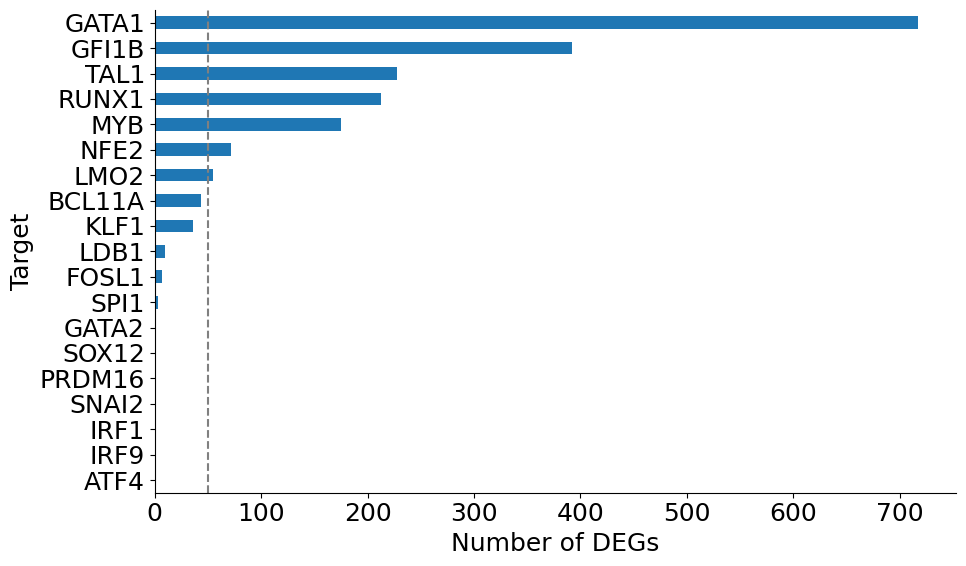

In [69]:
# plot number of DEGs per target (horizontal)
plt.figure(figsize=(10, 6))
degs_count = degs_filtered_df['group'].value_counts().sort_index()
# sort values by number of DEGs
degs_count = degs_count.sort_values(ascending=True)
degs_count.plot(kind='barh')
plt.xlabel('Number of DEGs')
plt.ylabel('Target')
# Add dotted vertical line at 50
plt.axvline(x=50, linestyle='--', color='grey')
# plt.title('Number of DEGs per Target')
plt.tight_layout()
plt.savefig(f'{res_dir}/num_degs_per_target.pdf', dpi=300, bbox_inches='tight')